# Travel Spending Analysis Using Python: A Month in China
## 1. Introduction

This project analyses a dataset of transactions collected during a month-long trip through China. The data was recorded personally throughout the trip and includes expenditure across categories such as accommodation, food, transport, and activities.

To enable geographic analysis, a secondary dataset was created mapping each period of travel to specific locations using start and end dates. This allows each transaction to be assigned to a city based on when and where it occurred.

The aim of the analysis is to explore spending patterns across both time and location, and to identify the main drivers of travel costs. Using Python for data cleaning, transformation, and visualisation, the project investigates how expenditure varies across categories, cities, and throughout the trip.

The analysis seeks to answer the following questions:

1. How much was spent on the trip?
2. Which categories accounted for the most spending?
3. Which categories accounted for the most spending?
4. Which locations were the most expensive?
5. What spending patterns can be observed across locations?

## 2. Data Loading

In [737]:
import pandas as pd
import matplotlib.pyplot as plt
# Load transaction data
spending_data = pd.read_csv("../Data/travelspend_export_China.csv")

# Load location mapping data
locations = pd.read_csv("../Data/China_Locations.csv")

display(spending_data.head())
locations.head()

,amount,amountInHomeCurrency,category,conversionRate,country,countryCode,datePaid,homeCurrency,localCurrency,description,...,addToBudget,categoryId,categoryIcon,categoryColor,paymentMethodId,paymentMethodIcon,paymentMethodColor,paidById,paidToId,splitObjects
0,193.79,193.79,Flights,1.0,United Kingdom,GB,07/02/2026,GBP,GBP,NaN,...,False,flight-false-504541934e46dc88caac2c0788e10519,flight,#4285F4,credit_card-73a61696f100b3858511e212a3feea6b,credit_card,#FFB300,oed6g60PYKc403dRjo0PbqOcGdp1,NaN,"[{'share':96900,'shareInHomeCurrency':96900,'f..."
1,37.30,37.30,Shopping,1.0,Vietnam,VN,06/02/2026,GBP,GBP,NaN,...,False,local_mall-false-fed561a86e066be5a26232626c4867a2,local_mall,#0F9D58,credit_card-73a61696f100b3858511e212a3feea6b,credit_card,#FFB300,IzRLzhnrlhMnWogwe049XldwR6m2,NaN,"[{'share':18650,'shareInHomeCurrency':18650,'f..."
2,37.03,37.03,Restaurants,1.0,Vietnam,VN,06/02/2026,GBP,GBP,NaN,...,False,restaurant-false-386c1f850fbd5f478fb4ef8a134c1740,restaurant,#009688,credit_card-73a61696f100b3858511e212a3feea6b,credit_card,#FFB300,IzRLzhnrlhMnWogwe049XldwR6m2,NaN,"[{'share':18520,'shareInHomeCurrency':18520,'f..."
3,2.03,2.03,Transportation,1.0,Vietnam,VN,06/02/2026,GBP,GBP,NaN,...,False,train-false-a600971fdd23ea1f5685d7ee01d5f5c3,train,#EF6C00,credit_card-73a61696f100b3858511e212a3feea6b,credit_card,#FFB300,oed6g60PYKc403dRjo0PbqOcGdp1,NaN,"[{'share':2030,'shareInHomeCurrency':2030,'for..."
4,6.00,6.00,Restaurants,1.0,Vietnam,VN,05/02/2026,GBP,GBP,NaN,...,False,restaurant-false-386c1f850fbd5f478fb4ef8a134c1740,restaurant,#009688,credit_card-73a61696f100b3858511e212a3feea6b,credit_card,#FFB300,IzRLzhnrlhMnWogwe049XldwR6m2,NaN,"[{'share':3000,'shareInHomeCurrency':3000,'for..."


,Place,country,start_date,end_date
0,Beijing,China,08/01/2026,10/01/2026
1,Gubeikou,China,10/01/2026,12/01/2026
2,Beijing,China,12/01/2026,13/01/2026
3,Pingyao,China,13/01/2026,14/01/2026
4,Xian,China,14/01/2026,18/01/2026


In [738]:
spending_data.info()
spending_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   amount                171 non-null    object 
 1   amountInHomeCurrency  171 non-null    object 
 2   category              171 non-null    object 
 3   conversionRate        171 non-null    float64
 4   country               171 non-null    object 
 5   countryCode           171 non-null    object 
 6   datePaid              171 non-null    object 
 7   homeCurrency          171 non-null    object 
 8   localCurrency         171 non-null    object 
 9   description           0 non-null      float64
 10  notes                 170 non-null    object 
 11  paidBy                171 non-null    object 
 12  paidFor               171 non-null    object 
 13  Izz                   171 non-null    object 
 14  Charlie               171 non-null    object 
 15  paymentMethod         1

amount                    0
amountInHomeCurrency      0
category                  0
conversionRate            0
country                   0
countryCode               0
datePaid                  0
homeCurrency              0
localCurrency             0
description             171
notes                     1
paidBy                    0
paidFor                   0
Izz                       0
Charlie                   0
paymentMethod             0
photo                   171
place                   105
latitude                105
longitude               105
type                      0
numberOfDays              0
excludeFromAvg            0
addToBudget               0
categoryId                0
categoryIcon              0
categoryColor             0
paymentMethodId           0
paymentMethodIcon         0
paymentMethodColor        0
paidById                  0
paidToId                171
splitObjects              0
dtype: int64

The transactions dataset contains detailed spending information including transaction amounts, dates, categories, currencies, and payment methods. Some fields are incomplete or irrelevant due to the structure of the export from a budgeting app.

The locations dataset was created to map each period of travel to specific locations using start and end dates, enabling geographic analysis of spending patterns across the trip.

## 3. Data Cleaning & Preparation

Initial inspection showed that the raw export contained many fields unrelated to the analysis. Only variables relevant to spending behaviour, categories, dates, and cost allocation were kept.

In [739]:
spending_data.columns

Index(['amount', 'amountInHomeCurrency', 'category', 'conversionRate',
       'country', 'countryCode', 'datePaid', 'homeCurrency', 'localCurrency',
       'description', 'notes', 'paidBy', 'paidFor', 'Izz', 'Charlie',
       'paymentMethod', 'photo', 'place', 'latitude', 'longitude', 'type',
       'numberOfDays', 'excludeFromAvg', 'addToBudget', 'categoryId',
       'categoryIcon', 'categoryColor', 'paymentMethodId', 'paymentMethodIcon',
       'paymentMethodColor', 'paidById', 'paidToId', 'splitObjects'],
      dtype='object')

In [740]:
# drop unnecessary columns
spending_data = spending_data[[
    "amountInHomeCurrency",
    "category",
    "datePaid",
    "homeCurrency",
    "paidFor",
    "Izz",
    "Charlie",
    "numberOfDays",
]].copy()

spending_data = spending_data.rename(
    columns={"amountInHomeCurrency": "amount (£)"})

spending_data.info()
spending_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   amount (£)    171 non-null    object
 1   category      171 non-null    object
 2   datePaid      171 non-null    object
 3   homeCurrency  171 non-null    object
 4   paidFor       171 non-null    object
 5   Izz           171 non-null    object
 6   Charlie       171 non-null    object
 7   numberOfDays  171 non-null    int64 
dtypes: int64(1), object(7)
memory usage: 10.8+ KB


,amount (£),category,datePaid,homeCurrency,paidFor,Izz,Charlie,numberOfDays
0,193.79,Flights,07/02/2026,GBP,"Izz,Charlie",96.90,96.89,1
1,37.30,Shopping,06/02/2026,GBP,"Izz,Charlie",18.65,18.65,1
2,37.03,Restaurants,06/02/2026,GBP,"Izz,Charlie",18.52,18.51,1
3,2.03,Transportation,06/02/2026,GBP,Charlie,0.00,2.03,1
4,6.00,Restaurants,05/02/2026,GBP,"Izz,Charlie",3.00,3.00,1


Date and monetary fields were converted to appropriate data types to enable time-series analysis and numerical calculations. Currency values contained formatting characters that were removed.

In [741]:
spending_data["datePaid"] = pd.to_datetime(spending_data["datePaid"], dayfirst=True)

# remove non-number characters from numeric columns
numeric_cols = ["amount (£)", "Izz", "Charlie"]

for col in numeric_cols:
    spending_data[col] = (spending_data[col].astype(str).str.replace(r"[^\d\.-]", "", regex=True))
    spending_data[col] = pd.to_numeric(spending_data[col])

spending_data.info()
spending_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   amount (£)    171 non-null    float64       
 1   category      171 non-null    object        
 2   datePaid      171 non-null    datetime64[ns]
 3   homeCurrency  171 non-null    object        
 4   paidFor       171 non-null    object        
 5   Izz           171 non-null    float64       
 6   Charlie       171 non-null    float64       
 7   numberOfDays  171 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 10.8+ KB


,amount (£),category,datePaid,homeCurrency,paidFor,Izz,Charlie,numberOfDays
0,193.79,Flights,2026-02-07,GBP,"Izz,Charlie",96.90,96.89,1
1,37.30,Shopping,2026-02-06,GBP,"Izz,Charlie",18.65,18.65,1
2,37.03,Restaurants,2026-02-06,GBP,"Izz,Charlie",18.52,18.51,1
3,2.03,Transportation,2026-02-06,GBP,Charlie,0.00,2.03,1
4,6.00,Restaurants,2026-02-05,GBP,"Izz,Charlie",3.00,3.00,1


The dataset was checked for missing values and duplicate transactions to assess overall data quality.

In [742]:
# check for null values and duplicate rows
display(spending_data.isnull().sum())
print(f"Duplicate rows: {spending_data.duplicated().sum()}")
spending_data[spending_data.duplicated(keep=False)]

amount (£)      0
category        0
datePaid        0
homeCurrency    0
paidFor         0
Izz             0
Charlie         0
numberOfDays    0
dtype: int64

Duplicate rows: 1


,amount (£),category,datePaid,homeCurrency,paidFor,Izz,Charlie,numberOfDays
133,0.54,Transportation,2026-01-13,GBP,Charlie,0.0,0.54,1
134,0.54,Transportation,2026-01-13,GBP,Charlie,0.0,0.54,1


Duplicate transaction was reviewed and confirmed to be a duplicate record, so it was removed.

In [743]:
spending_data = spending_data.drop_duplicates()

Spending categories were standardised to improve consistency. Food and drink purchases were combined into a single category, while ambiguous categories were renamed.

In [744]:
spending_data["category"].value_counts()

category
Restaurants       69
Transportation    45
Accommodation     29
Sightseeing       15
Coffee             4
Flights            3
Shopping           3
Fees & Charges     2
Name: count, dtype: int64

In [745]:
spending_data["category"] = spending_data["category"].replace({
    "Restaurants": "Food & Drink",
    "Coffee": "Food & Drink",
    "Fees & Charges": "Miscellaneous",
    "Sightseeing": "Sightseeing & Activities"
})
spending_data["category"].value_counts()

category
Food & Drink                73
Transportation              45
Accommodation               29
Sightseeing & Activities    15
Flights                      3
Shopping                     3
Miscellaneous                2
Name: count, dtype: int64

Final validation checks were performed to confirm the expected date range and ensure text fields were consistently formatted.

In [746]:
spending_data["datePaid"].min(), spending_data["datePaid"].max()

(Timestamp('2026-01-01 00:00:00'), Timestamp('2026-02-07 00:00:00'))

In [747]:
# remove white spaces from text fields
text_cols = ["category", "paidFor"]

for col in text_cols:
    spending_data[col] = spending_data[col].str.strip()

spending_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 170 entries, 0 to 170
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   amount (£)    170 non-null    float64       
 1   category      170 non-null    object        
 2   datePaid      170 non-null    datetime64[ns]
 3   homeCurrency  170 non-null    object        
 4   paidFor       170 non-null    object        
 5   Izz           170 non-null    float64       
 6   Charlie       170 non-null    float64       
 7   numberOfDays  170 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 12.0+ KB


The location dataset containing start and end dates for each destination was used to assign every transaction to a place. This enabled geographic analysis of spending patterns across the trip.

In [748]:
# convert location dates to datetime format
locations["start_date"] = pd.to_datetime(locations["start_date"], dayfirst=True)
locations["end_date"] = pd.to_datetime(locations["end_date"], dayfirst=True)

# Assign each transaction to a location based on its date
def get_location(transaction_date):
    
    match = locations[
        (locations["start_date"] <= transaction_date) &
        (transaction_date < locations["end_date"])
    ]
    
    if not match.empty:
        return match.iloc[0]["Place"]
    
    return None

spending_data["Place"] = (spending_data["datePaid"].apply(get_location))

spending_data.head()

,amount (£),category,datePaid,homeCurrency,paidFor,Izz,Charlie,numberOfDays,Place
0,193.79,Flights,2026-02-07,GBP,"Izz,Charlie",96.90,96.89,1,None
1,37.30,Shopping,2026-02-06,GBP,"Izz,Charlie",18.65,18.65,1,Shanghai
2,37.03,Food & Drink,2026-02-06,GBP,"Izz,Charlie",18.52,18.51,1,Shanghai
3,2.03,Transportation,2026-02-06,GBP,Charlie,0.00,2.03,1,Shanghai
4,6.00,Food & Drink,2026-02-05,GBP,"Izz,Charlie",3.00,3.00,1,Shanghai


In [749]:
print(f"Transactions without a location match: {spending_data['Place'].isnull().sum()}")

spending_data.loc[
    spending_data["Place"].isnull(),
    ["datePaid", "category", "amount (£)"]
]

Transactions without a location match: 3


,datePaid,category,amount (£)
0,2026-02-07,Flights,193.79
169,2026-01-06,Flights,751.76
170,2026-01-01,Miscellaneous,72.67


The transactions without a location match were checked and confirmed to be the outbound and return flights, and pre-trip purchases.

## 4. Exploratory Data Analysis

### Question 1: How much was spent on the trip?

In [762]:
num_of_entries = len(df_transactions)

total_spend = spending_data["amount (£)"].sum()

num_of_days = spending_data["datePaid"].nunique()

avg_daily_spend = total_spend/num_of_days

print (f"number of entries: {num_of_entries}")
print(f"total spend: £{total_spend:,.2f}")
print(f"average daily spend: £{avg_daily_spend:,.2f}")

number of entries: 170
total spend: £3,488.82
average daily spend: £105.72


### Question 2: Which categories accounted for the most spending?

In [751]:
category_spend = (spending_data.groupby("category")["amount (£)"].sum().sort_values(ascending=False))

category_pct = (category_spend / category_spend.sum() * 100).round(1)

category_summary = pd.DataFrame({"Spend (£)": category_spend,"Percentage (%)": category_pct})

category_summary

,Spend (£),Percentage (%)
category,,
Flights,1041.26,29.8
Food & Drink,851.09,24.4
Accommodation,782.30,22.4
Transportation,515.69,14.8
Sightseeing & Activities,150.89,4.3
Miscellaneous,83.30,2.4
Shopping,64.29,1.8


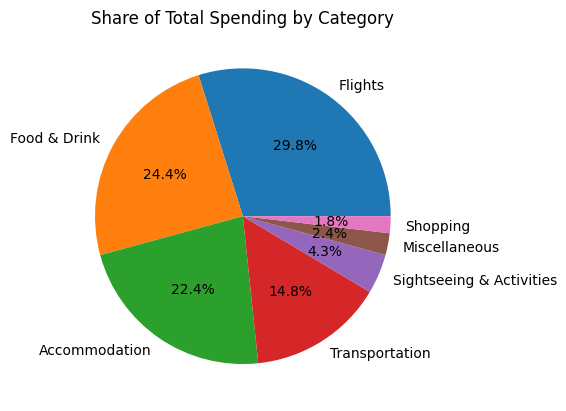

In [752]:
# create pie chart of spending by catagories
category_spend.plot.pie(
    autopct="%1.1f%%",
    ylabel=""
)

plt.title("Share of Total Spending by Category")
plt.show()

Flights accounted for the largest share of spending, followed by food & drink and Accommodation. These three categories made up the majority of total expenditure, reflecting the importance of day-to-day living costs and inter-city travel.

Smaller categories such as Shopping and Fees & Charges represented only a minor proportion of overall spending, suggesting that discretionary purchases had limited impact on total costs.

### Question 3: How did spending change over time?

In [753]:
# calculate total spending for each day of the trip
daily_spend = (spending_data.groupby("datePaid")["amount (£)"].sum().reset_index().sort_values("datePaid"))

daily_spend.head()

,datePaid,amount (£)
0,2026-01-01,72.67
1,2026-01-06,751.76
2,2026-01-08,97.67
3,2026-01-09,48.18
4,2026-01-10,89.25


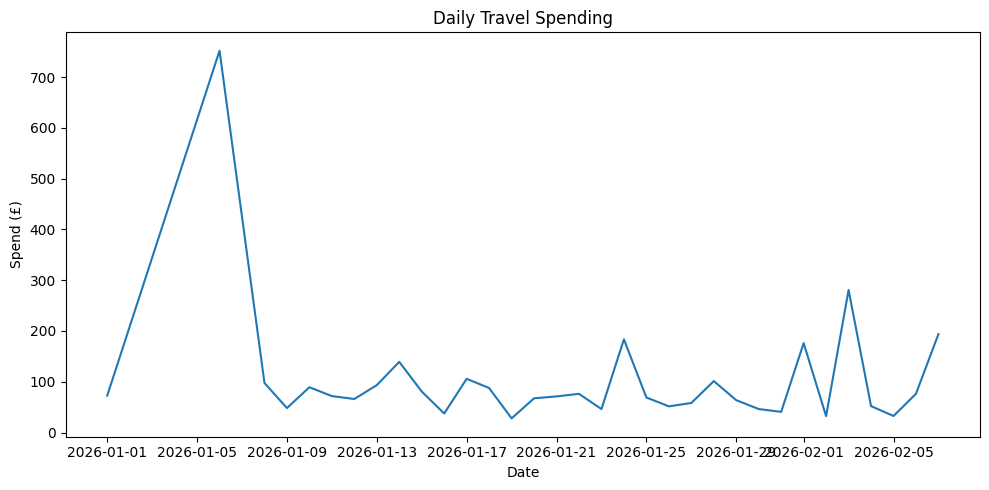

In [754]:
# create graph of spending over time
plt.figure(figsize=(10,5))

plt.plot(daily_spend["datePaid"], daily_spend["amount (£)"])

plt.title("Daily Travel Spending")
plt.xlabel("Date")
plt.ylabel("Spend (£)")

plt.tight_layout()
plt.show()

Daily spending remained relatively stable across most of the trip, with occasional sharp spikes.

The largest peaks occur at the beginning and end of the period, which correspond to flights. Smaller fluctuations throughout the trip are driven by accommodation payments, food expenses, and inter-city travel.

Overall, the data suggests a consistent level of day-to-day spending once major travel costs are excluded.

### Question 4: Which locations were the most expensive?

To compare spending fairly across destinations, total expenditure was normalised by the number of days spent in each location. This allows us to identify where daily spending was highest, rather than simply where the most money was spent overall.

In [755]:
# create df that excludes travel between each place
location_transactions = spending_data[
    (spending_data["category"] != "Flights") &
    ~(
        (spending_data["category"] == "Transportation") &
        (spending_data["amount (£)"] > 36)
    )
]

To analyse spending within destinations, flights and long-distance transportation costs above £36 were excluded. These transactions represented travel between locations rather than spending within a specific destination.

In [756]:
# calculate number of days for each location
locations["days"] = (locations["end_date"] - locations["start_date"]).dt.days

# calculate total spend for each location
location_summary = (
    location_transactions
    .groupby("Place")["amount (£)"]
    .sum()
    .reset_index()
)

# add trip duration for each location
location_summary = location_summary.merge(
    locations.groupby("Place")["days"].sum().reset_index(), on="Place"
)

# calculate average daily spend
location_summary["spend_per_day"] = (location_summary["amount (£)"] / location_summary["days"])

location_summary.sort_values("spend_per_day", ascending=False)

,Place,amount (£),days,spend_per_day
7,Shanghai,346.08,4,86.520000
5,Lijiang,324.06,4,81.015000
4,Gubeikou,161.01,2,80.505000
0,Beijing,211.93,3,70.643333
10,Xian,265.39,4,66.347500
1,Chengdu,376.61,6,62.768333
9,Xaxi,110.04,2,55.020000
8,Tiger Leaping Gorge,51.60,1,51.600000
2,Chongqing,85.77,2,42.885000
3,Dali,40.72,1,40.720000


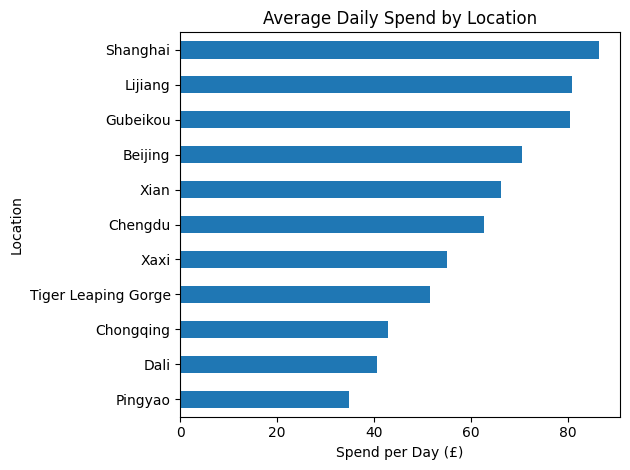

In [757]:
# create bar chart for average daily spend by location
location_summary.sort_values("spend_per_day").plot.barh(
    x="Place",
    y="spend_per_day",
    legend=False
)

plt.title("Average Daily Spend by Location")
plt.xlabel("Spend per Day (£)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

Average daily spend varied significantly across locations.

Some cities showed much higher daily costs, indicating more expensive accommodation or higher day-to-day living expenses. Other locations were comparatively cheaper, despite sometimes having higher total spend due to longer stays.

This demonstrates that total expenditure alone does not accurately reflect cost intensity, and normalising by duration provides a clearer comparison of relative affordability across destinations.

### Question 5: What spending patterns can be observed across locations?

In [758]:
# create a table showing total spend by category for each location
location_category = pd.pivot_table(
    location_transactions,
    values="amount (£)",
    index="Place",
    columns="category",
    aggfunc="sum",
    fill_value=0
)

# convert total spending into average daily spending
days_per_place = (locations.groupby("Place")["days"].sum())
location_category_daily = location_category.div(days_per_place, axis=0)

# order locations by travel sequence
location_order = locations.sort_values("start_date")["Place"].drop_duplicates()
location_category_daily = location_category_daily.reindex(location_order)

location_category_daily

category,Accommodation,Food & Drink,Miscellaneous,Shopping,Sightseeing & Activities,Transportation
Place,,,,,,
Beijing,35.146667,22.673333,3.543333,0.0000,5.120000,4.160000
Gubeikou,29.070000,27.290000,0.000000,0.0000,5.880000,18.265000
Pingyao,17.590000,14.360000,0.000000,0.0000,0.000000,2.850000
Xian,17.985000,22.107500,0.000000,1.4700,16.207500,8.577500
Chengdu,20.466667,25.851667,0.000000,0.0000,9.823333,6.626667
Lijiang,37.690000,34.295000,0.000000,5.2775,0.000000,3.752500
Tiger Leaping Gorge,21.110000,30.490000,0.000000,0.0000,0.000000,0.000000
Xaxi,18.910000,36.110000,0.000000,0.0000,0.000000,0.000000
Dali,4.680000,36.040000,0.000000,0.0000,0.000000,0.000000


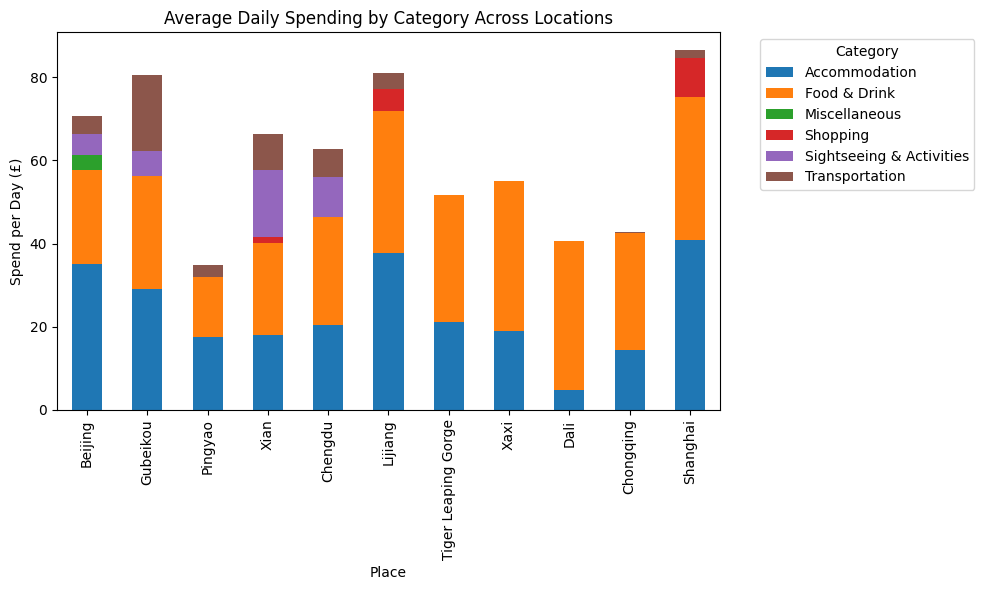

In [769]:
# create stacked bar chart of average daily spending by category for each location
location_category_daily.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Average Daily Spending by Category Across Locations")
plt.ylabel("Spend per Day (£)")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1),loc="upper left")
plt.tight_layout()
plt.show()

Clear differences can be observed in spending patterns across locations.

Food & Drink and Accommodation consistently account for the largest proportion of spending across most destinations, reflecting essential day-to-day travel costs.

Some locations show higher transportation spend, likely due to inter-city travel or local transport usage. In contrast, shopping and sighseeing & activities spending is inconsistent. Some locations show no spending in these categories at all, while others show small, sporadic amounts. This suggests these categories are opportunistic rather than habitual.

Overall, the results indicate that while total spending varies between locations, the underlying structure of essential spending remains broadly consistent across the trip.

## 6. Key Insights

## Key Insights

- Total trip expenditure was £3,488.82 across 170 entries, with an average daily spend of £105.72.

- Flights were the largest overall spending category, driven by a small number of high-value transactions at the beginning and end of the trip.

- This was followed by food & drink and accommodation, which together formed the core of day-to-day travel expenditure.

- Spending over time was relatively consistent, with large spikes caused by flights and inter-city transportation.

- There was significant variation in average daily spend across locations, with Shanghai being more than twice as expensive per day as Pingyao, largely driven by higher accommodation and general living costs.

- While essential spending categories were consistent across all locations, discretionary spending such as Shopping was irregular and highly location-dependent.

## 7. Conclusions

This analysis provided an overview of spending behaviour across a multi-city trip, highlighting how costs were distributed across categories, time, and locations.

Overall, spending was primarily driven by essential categories such as food & drink, and accommodation with flights representing large one-off costs that significantly influenced total expenditure.

While total spend varied between locations, normalising by duration showed that differences in cost were influenced by both the length of stay and variation in accommodation costs. There were also notable differences in average daily spend across certain locations, indicating that some cities were significantly more expensive on a day-to-day basis than others.

Discretionary spending such as Shopping and Miscellaneous was relatively minor and inconsistent, reinforcing that the majority of expenditure was driven by necessary travel-related costs rather than optional spending.